Part 01

01.

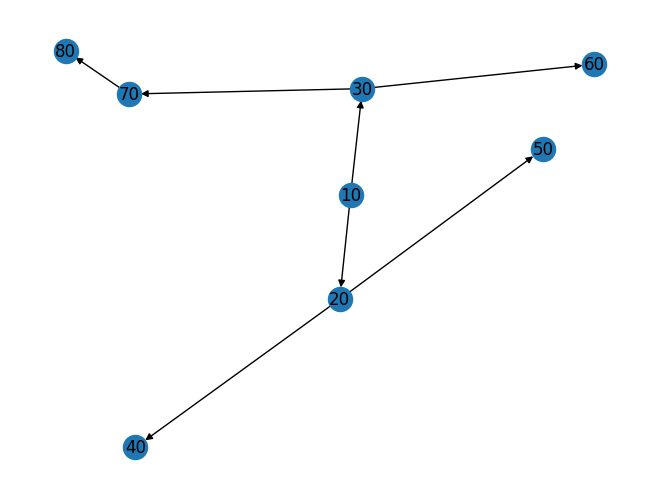

Parent of 40: [20]
Height of tree: 3


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# I. Visualize the tree
T = nx.DiGraph()
T.add_edges_from([(10,20),(10,30),(20,40),(20,50),(30,60),(30,70),(70,80)])

nx.draw(T, with_labels=True)
plt.show()

# II. Find parent of node 40
parent = list(T.predecessors(40))
print("Parent of 40:", parent)

# III. Height of the tree
depths = nx.shortest_path_length(T, source=10)
height = max(depths.values())
print("Height of tree:", height)

02.

In [2]:
import networkx as nx

T = nx.DiGraph()
T.add_edges_from([(10,20),(10,30),(20,40),(20,50),(30,60),(30,70),(70,80)])

# I. Leaf nodes (nodes with no children)
leaf_nodes = [n for n in T.nodes() if T.out_degree(n) == 0]
print("Leaf nodes:", leaf_nodes)

# II. Root node (node with no parent)
root = [n for n in T.nodes() if T.in_degree(n) == 0]
print("Root node:", root)

# III. Siblings of node 50 (same parent)
parent_of_50 = list(T.predecessors(50))[0]
siblings = [n for n in T.successors(parent_of_50) if n != 50]
print("Siblings of 50:", siblings)

# IV. Depth to node 70 from root
depth = nx.shortest_path_length(T, source=10, target=70)
print("Depth to node 70:", depth)

Leaf nodes: [40, 50, 60, 80]
Root node: [10]
Siblings of 50: [40]
Depth to node 70: 2


03.

In [3]:
import networkx as nx

T = nx.DiGraph()
T.add_edges_from([('ER','TRIAGE'),('ER','ICU'),('ICU','SURG'),('ICU','CARD'),('SURG','NEURO')])

# Check if binary tree (every node has at most 2 children)
is_binary = all(T.out_degree(n) <= 2 for n in T.nodes())
print("Is Binary Tree:", is_binary)

Is Binary Tree: True


4.

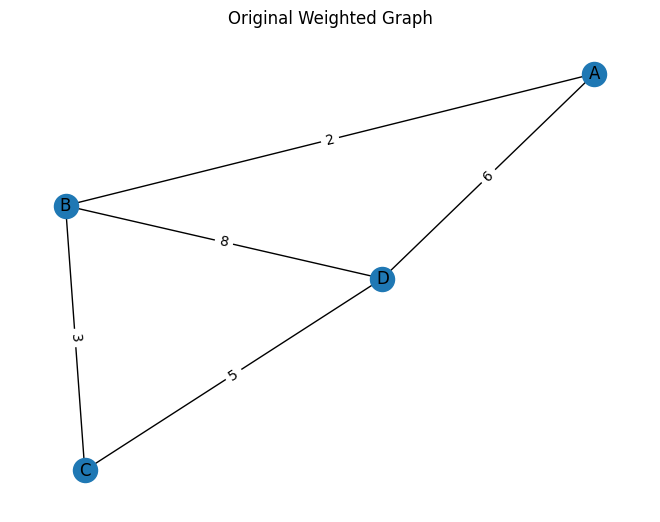

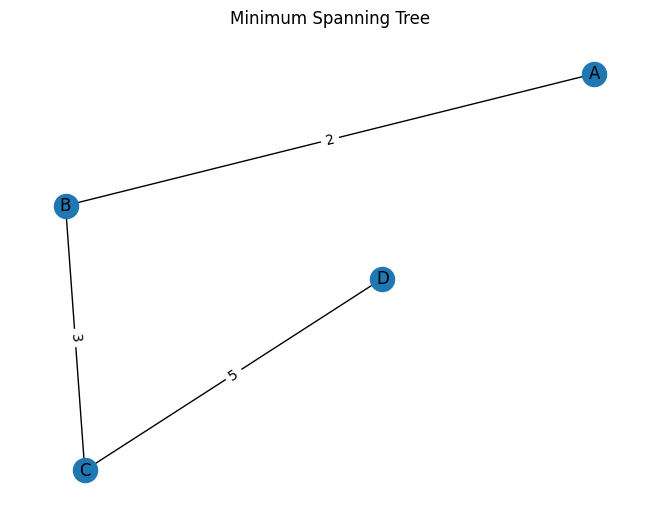

MST edges: [('A', 'B', {'weight': 2}), ('B', 'C', {'weight': 3}), ('D', 'C', {'weight': 5})]


In [4]:
import networkx as nx
import matplotlib.pyplot as plt

# I. Create and visualize weighted graph
G = nx.Graph()
G.add_weighted_edges_from([('A','B',2),('A','D',6),('B','C',3),('B','D',8),('C','D',5)])

pos = nx.spring_layout(G)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Original Weighted Graph")
plt.show()

# II. Find MST using Prim's
MST = nx.minimum_spanning_tree(G, algorithm='prim')
nx.draw(MST, pos, with_labels=True)
nx.draw_networkx_edge_labels(MST, pos, edge_labels=nx.get_edge_attributes(MST,'weight'))
plt.title("Minimum Spanning Tree")
plt.show()

print("MST edges:", list(MST.edges(data=True)))

5.

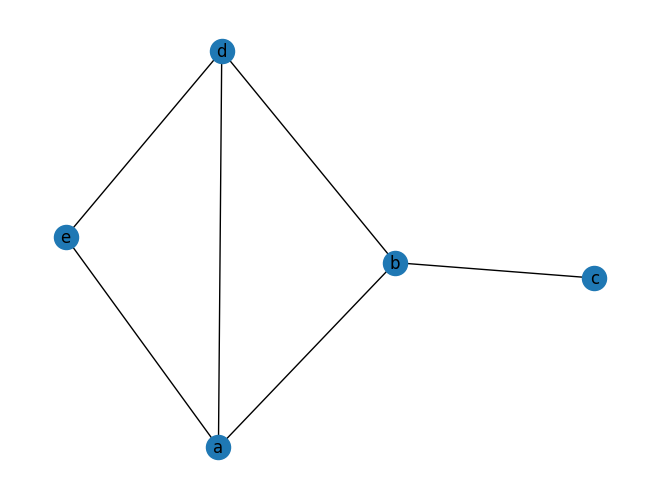

BFS visiting order: ['a', 'b', 'e', 'd', 'c']


In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from([('a','b'),('a','e'),('a','d'),('b','d'),('b','c'),('d','e')])

nx.draw(G, with_labels=True)
plt.show()

bfs = nx.bfs_tree(G, source='a')
print("BFS visiting order:", list(bfs.nodes()))

Part 02

1.

import networkx as nx
import matplotlib.pyplot as plt

T = nx.DiGraph()
T.add_edges_from([(1,2),(1,8),(1,9),(2,6),(2,5),(8,7),(5,3),(5,4)])

nx.draw(T, with_labels=True)
plt.show()

# I. Parent of node 7
parent = list(T.predecessors(7))
print("Parent of 7:", parent)

# II. Height of tree
depths = nx.shortest_path_length(T, source=1)
height = max(depths.values())
print("Height of tree:", height)

2.

In [7]:
def is_full_binary_tree(tree):
    n = len(tree)
    for i in range(n):
        if tree[i] is None:
            continue
        left  = 2 * i + 1
        right = 2 * i + 2
        left_exists  = left  < n and tree[left]  is not None
        right_exists = right < n and tree[right] is not None
        # Full binary: node must have 0 or 2 children
        if left_exists != right_exists:
            return False
    return True

tree = [1, 2, 3, 4, 5, None, None]
print("Is Full Binary Tree:", is_full_binary_tree(tree))

Is Full Binary Tree: True


3.

In [9]:
import networkx as nx

T = nx.DiGraph()
T.add_edges_from([('ADMIN','SCIENCE'),('ADMIN','ARTS'),
                  ('SCIENCE','PHYSICS'),('SCIENCE','CHEMISTRY'),
                  ('ARTS','HISTORY'),('ARTS','LANGUAGES')])

# Full binary tree: every node has 0 or 2 children
is_full = all(T.out_degree(n) == 0 or T.out_degree(n) == 2 for n in T.nodes())
print("Is Full Binary Tree:", is_full)

Is Full Binary Tree: True


4.

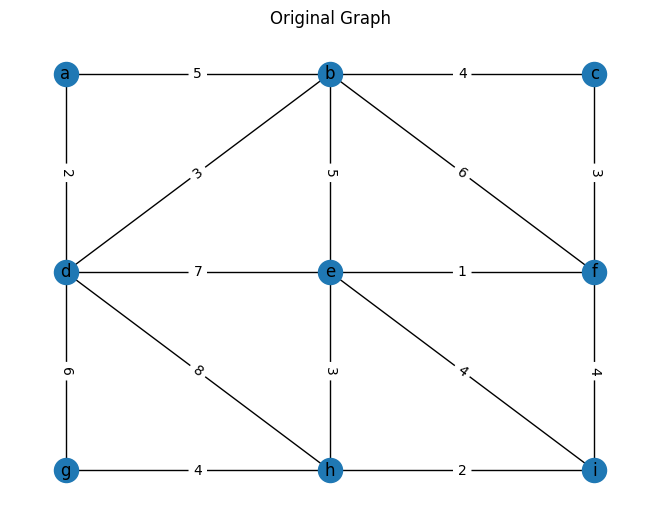

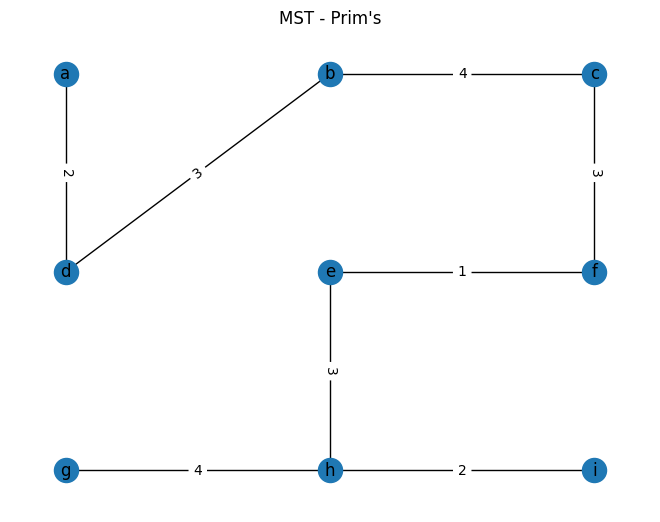

MST edges: [('a', 'd', {'weight': 2}), ('b', 'c', {'weight': 4}), ('b', 'd', {'weight': 3}), ('c', 'f', {'weight': 3}), ('f', 'e', {'weight': 1}), ('e', 'h', {'weight': 3}), ('g', 'h', {'weight': 4}), ('i', 'h', {'weight': 2})]


In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_weighted_edges_from([
    ('a','b',5),('b','c',4),
    ('a','d',2),('c','f',3),
    ('d','e',7),('e','f',1),
    ('d','g',6),('f','i',4),
    ('g','h',4),('h','i',2),
    ('b','d',3),('b','e',5),
    ('b','f',6),('d','h',8),
    ('e','h',3),('e','i',4)
])

pos = {'a':(0,2),'b':(1,2),'c':(2,2),
       'd':(0,1),'e':(1,1),'f':(2,1),
       'g':(0,0),'h':(1,0),'i':(2,0)}

labels = nx.get_edge_attributes(G,'weight')
nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Original Graph")
plt.show()

MST = nx.minimum_spanning_tree(G, algorithm='prim')
nx.draw(MST, pos, with_labels=True)
nx.draw_networkx_edge_labels(MST, pos, edge_labels=nx.get_edge_attributes(MST,'weight'))
plt.title("MST - Prim's")
plt.show()

print("MST edges:", list(MST.edges(data=True)))

5.

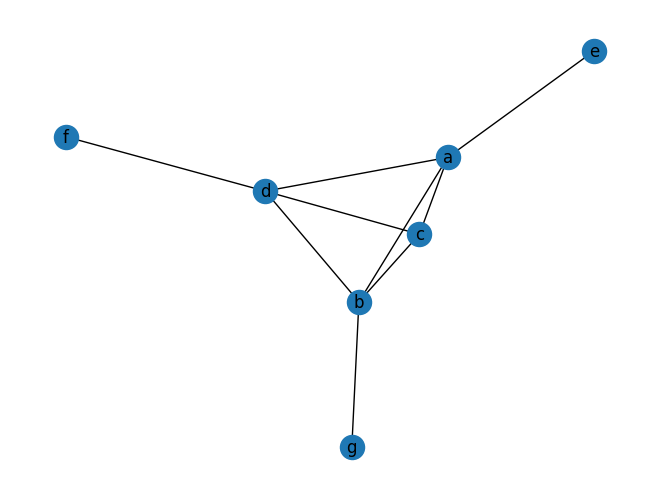

DFS visiting order: ['a', 'b', 'c', 'd', 'f', 'g', 'e']


In [11]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from([('a','b'),('a','c'),('a','d'),
                  ('b','c'),('b','d'),('b','g'),
                  ('c','d'),('d','f'),('e','a')])

nx.draw(G, with_labels=True)
plt.show()

dfs = nx.dfs_tree(G, source='a')
print("DFS visiting order:", list(dfs.nodes()))